In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
import joblib
import pickle
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
import warnings

warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
data = 'D:/Ishita/IGDTUW (CSE)/Summer Internship 2024/Analytics (NER) Healthcare/Datasets/i2b2_2012_annotated.csv'
df = pd.read_csv(data, header=None)

In [4]:
df.columns = df.iloc[0]
df = df[1:]
df.head()

,Record,Word,POS,IOB,Tag
1,1,Admission,NN,B-NP,B-OCCURRENCE
2,1,Date,NNP,I-NP,O
3,1,:,:,O,O
4,1,09/29/1993,CD,O,B-DATE
5,1,09/29/1993,CD,O,B-ADMISSION


In [5]:
import re
import spacy

import nltk
import string
#nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
STOP_WORDS = stopwords.words('english')
def clean_word(word):
    
    # remove non-alphanumeric characters and extra whitespaces
    word = re.sub(r'[^\w\s]','',word)
    word = re.sub(r'\s+',' ',word)
    
    # convert to lowercase
    word = word.lower()
    
    if word not in STOP_WORDS:
        return word
    
    return ''

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
words = list(set(df["Word"].values))
words.append("ENDPAD")
num_words = len(words)
words_set = set(words)

# Clean and convert each word in df['Word']
df['Word'] = df['Word'].astype(str).apply(clean_word)

# Filter df to keep rows where 'Word' is in words_set
df = df[df['Word'].isin(words_set)]
words = list(set(df["Word"].values))
words.append("ENDPAD")
num_words = len(words)


tags = list(set(df["Tag"].values))
num_tags = len(tags)
word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}

In [7]:
print("Unique words in corpus:", df['Word'].nunique())
print("Unique tags in corpus:", df['Tag'].nunique())

Unique words in corpus: 5528
Unique tags in corpus: 21


In [8]:
print(df['Tag'].value_counts())

O                  18271
I-PROBLEM           6200
B-PROBLEM           3631
I-TREATMENT         3116
I-TEST              2872
B-OCCURRENCE        2821
B-TREATMENT         2464
I-OCCURRENCE        1537
I-CLINICAL_DEPT     1368
B-TEST              1269
I-DATE              1069
B-EVIDENTIAL         713
I-DURATION           532
B-DATE               388
B-DURATION           282
B-FREQUENCY          222
B-CLINICAL_DEPT      173
I-FREQUENCY          148
I-EVIDENTIAL          61
I-TIME                48
B-TIME                17
Name: Tag, dtype: int64


In [9]:
import tqdm
def sentence_integrate(data):
  agg_func = lambda s: [(w, p, i, t) for w, p, i, t in zip(s["Word"].values.tolist(),
                                                           s["POS"].values.tolist(),
                                                           s["IOB"].values.tolist(),
                                                           s["Tag"].values.tolist())]
  return df.groupby('Record').apply(agg_func).tolist()
  
sentences=sentence_integrate(data)
  
sentences[0]


[('admission', 'NN', 'B-NP', 'B-OCCURRENCE'),
 ('date', 'NNP', 'I-NP', 'O'),
 ('discharge', 'NN', 'B-NP', 'B-OCCURRENCE'),
 ('date', 'NNP', 'I-NP', 'O'),
 ('history', 'NN', 'B-NP', 'O'),
 ('present', 'NNP', 'I-NP', 'O'),
 ('illness', 'NNP', 'I-NP', 'O'),
 ('patient', 'NN', 'I-NP', 'O'),
 ('woman', 'NN', 'I-NP', 'O'),
 ('positive', 'JJ', 'O', 'I-PROBLEM'),
 ('two', 'CD', 'O', 'B-DURATION'),
 ('years', 'NNS', 'B-NP', 'I-DURATION'),
 ('presented', 'VBD', 'B-VP', 'B-EVIDENTIAL'),
 ('left', 'JJ', 'B-NP', 'B-PROBLEM'),
 ('upper', 'JJ', 'I-NP', 'I-PROBLEM'),
 ('quadrant', 'NN', 'I-NP', 'I-PROBLEM'),
 ('pain', 'NN', 'I-NP', 'I-PROBLEM'),
 ('well', 'RB', 'O', 'O'),
 ('nausea', 'NN', 'B-NP', 'B-PROBLEM'),
 ('vomiting', 'NN', 'B-NP', 'B-PROBLEM'),
 ('longstanding', 'JJ', 'I-NP', 'I-PROBLEM'),
 ('complaint', 'NN', 'I-NP', 'I-PROBLEM'),
 ('diagnosed', 'VBN', 'O', 'B-OCCURRENCE'),
 ('1991', 'CD', 'O', 'B-DATE'),
 ('birth', 'NN', 'I-NP', 'I-OCCURRENCE'),
 ('child', 'NN', 'B-NP', 'I-OCCURRENCE'),
 ('c

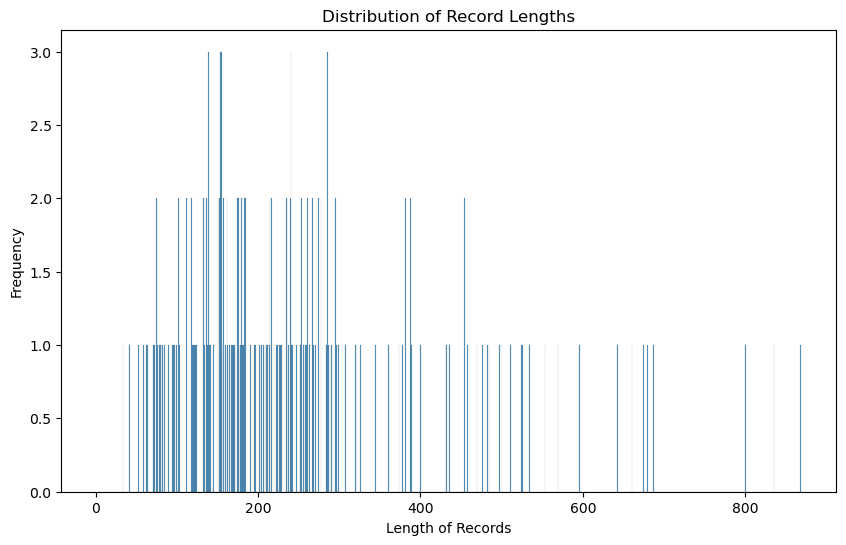

In [10]:
sentence_lengths = [len(sentence) for sentence in sentences]

# Plot the distribution
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(sentence_lengths, bins=range(1, max(sentence_lengths) + 2), kde=False)
plt.title('Distribution of Record Lengths')
plt.xlabel('Length of Records')
plt.ylabel('Frequency')
plt.show()

In [11]:
print(sum(length > 500 for length in sentence_lengths))

15


In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 500

X = [[word2idx[w[0]] for w in s] for s in sentences]
X = pad_sequences(maxlen=max_len, sequences=X, padding="post", value=num_words-1)

y = [[tag2idx[w[3]] for w in s] for s in sentences]
y = pad_sequences(maxlen=max_len, sequences=y, padding="post", value=tag2idx["O"])

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size = 0.5, random_state = 42)

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.optimizers.legacy import Adam

In [15]:
# Define the model architecture
INPUT_DIM = 5529
EMBEDDING_DIM = 64
MAX_LENGTH = 500
NUM_CLASSES = 23
LSTM1_UNITS = 64
LSTM2_UNITS = 32
DENSE_DIM = 64
DROPOUT = 0.2
BATCH_SIZE = 32
EPOCHS = 75
model = tf.keras.models.Sequential([
    Embedding(INPUT_DIM, EMBEDDING_DIM, input_length=MAX_LENGTH),
    Bidirectional(LSTM(units=LSTM1_UNITS, return_sequences=True)),
    Bidirectional(LSTM(units=LSTM2_UNITS, return_sequences=True)),
    Dense(DENSE_DIM, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])


model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 500, 64)           353856    
                                                                 
 bidirectional (Bidirectiona  (None, 500, 128)         66048     
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 500, 64)          41216     
 nal)                                                            
                                                                 
 dense (Dense)               (None, 500, 64)           4160      
                                                                 
 dense_1 (Dense)             (None, 500, 23)           1495      
                                                                 
Total params: 466,775
Trainable params: 466,775
Non-trai

In [16]:
# Train the model
history = model.fit(
    X_train, 
    y_train, 
    epochs=EPOCHS, 
    validation_data=(X_val, y_val)
)

Epoch 1/75
5/5 [==============================] - 10s 804ms/step - loss: 3.0860 - accuracy: 0.4703 - val_loss: 2.9531 - val_accuracy: 0.6682
Epoch 2/75
5/5 [==============================] - 2s 432ms/step - loss: 2.7130 - accuracy: 0.7132 - val_loss: 2.2305 - val_accuracy: 0.6682
Epoch 3/75
5/5 [==============================] - 2s 428ms/step - loss: 1.7182 - accuracy: 0.7132 - val_loss: 1.6083 - val_accuracy: 0.6682
Epoch 4/75
5/5 [==============================] - 2s 419ms/step - loss: 1.4766 - accuracy: 0.7132 - val_loss: 1.7106 - val_accuracy: 0.6682
Epoch 5/75
5/5 [==============================] - 2s 420ms/step - loss: 1.4444 - accuracy: 0.7132 - val_loss: 1.5495 - val_accuracy: 0.6682
Epoch 6/75
5/5 [==============================] - 2s 416ms/step - loss: 1.3580 - accuracy: 0.7132 - val_loss: 1.4943 - val_accuracy: 0.6682
Epoch 7/75
5/5 [==============================] - 2s 419ms/step - loss: 1.3317 - accuracy: 0.7132 - val_loss: 1.4466 - val_accuracy: 0.6682
Epoch 8/75
5/5 [===

In [17]:
predictions = [model.predict(np.array([x])) for x in X_test]
predicted_labels = [np.argmax(pred[0], axis=-1) for pred in predictions]

# Flatten the test labels and predicted labels
y_test_flat = [label for sublist in y_test for label in sublist]
predicted_labels_flat = [label for sublist in predicted_labels for label in sublist]


1/1 [==============================] - 0s 106ms/step


In [18]:
# Print classification report
print(classification_report(y_test_flat, predicted_labels_flat))

              precision    recall  f1-score   support

           0       0.52      0.53      0.53       259
           1       0.58      0.71      0.64       128
           2       0.35      0.35      0.35        20
           3       0.54      0.58      0.56       560
           4       0.40      0.49      0.44        77
           5       0.54      0.25      0.34        79
           6       0.22      0.18      0.20       158
           7       0.93      0.95      0.94      6796
           8       0.46      0.54      0.50       249
           9       0.54      0.66      0.59       290
          10       0.00      0.00      0.00        29
          11       0.00      0.00      0.00        23
          12       0.49      0.34      0.40       265
          13       0.00      0.00      0.00        10
          14       0.00      0.00      0.00         3
          15       0.46      0.35      0.40       360
          16       0.00      0.00      0.00         1
          17       0.26    

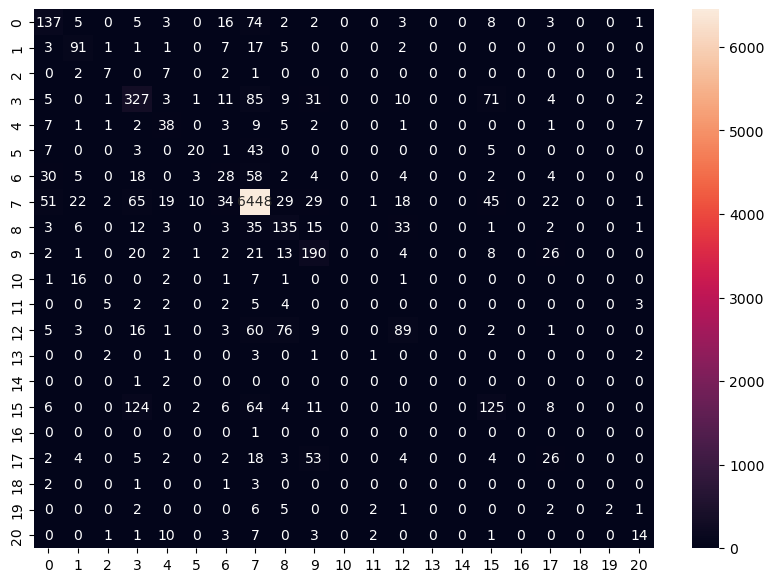

In [19]:
cm=tf.math.confusion_matrix(y_test_flat, predicted_labels_flat)
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel=('Predicted')
plt.ylabel=('Truth')